In [1]:
import sys
import torch

sys.path.append('C:/Users/MSI LAPTOP/landmark-classifier')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Usando: {device}")

Usando: cuda


In [2]:
from src.data import get_data_loaders

DATA_DIR = 'C:/Users/MSI LAPTOP/landmark_images/landmark_images'

train_loader, val_loader, test_loader, class_names = get_data_loaders(
    data_dir=DATA_DIR,
    batch_size=32,
    val_split=0.2,
    num_workers=2
)
print(f"Clases cargadas: {len(class_names)}")

Clases encontradas : 50
Imágenes en train  : 3997
Imágenes en val    : 999
Imágenes en test   : 1250
Clases cargadas: 50


In [3]:
from src.model import get_transfer_model

model = get_transfer_model(
    model_name  = 'resnet50',
    num_classes = 50,
    device      = device
)

# Cargar los pesos guardados
model.load_state_dict(torch.load(
    'C:/Users/MSI LAPTOP/landmark-classifier/models/best_resnet50.pt',
    map_location=device
))
model.eval()
print("Modelo cargado ✓")

Modelo: resnet50
Parámetros totales    : 24,045,426
Parámetros entrenables: 537,394  (2.2%)
Modelo cargado ✓


C:\Users\MSI LAPTOP\AppData\Local\Temp\ipykernel_40212\3598131115.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(


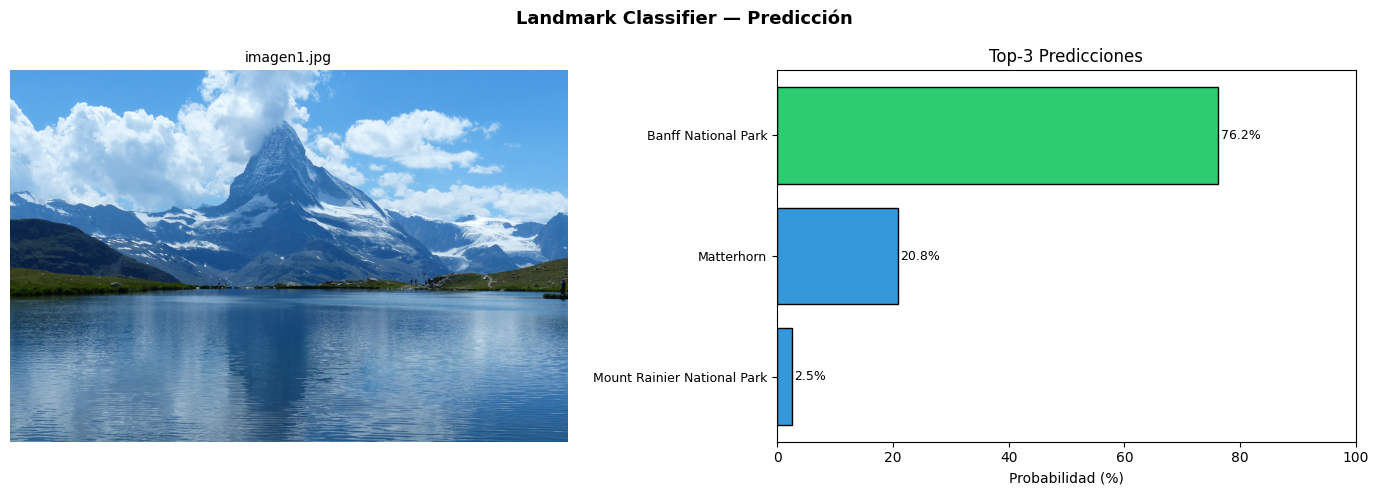

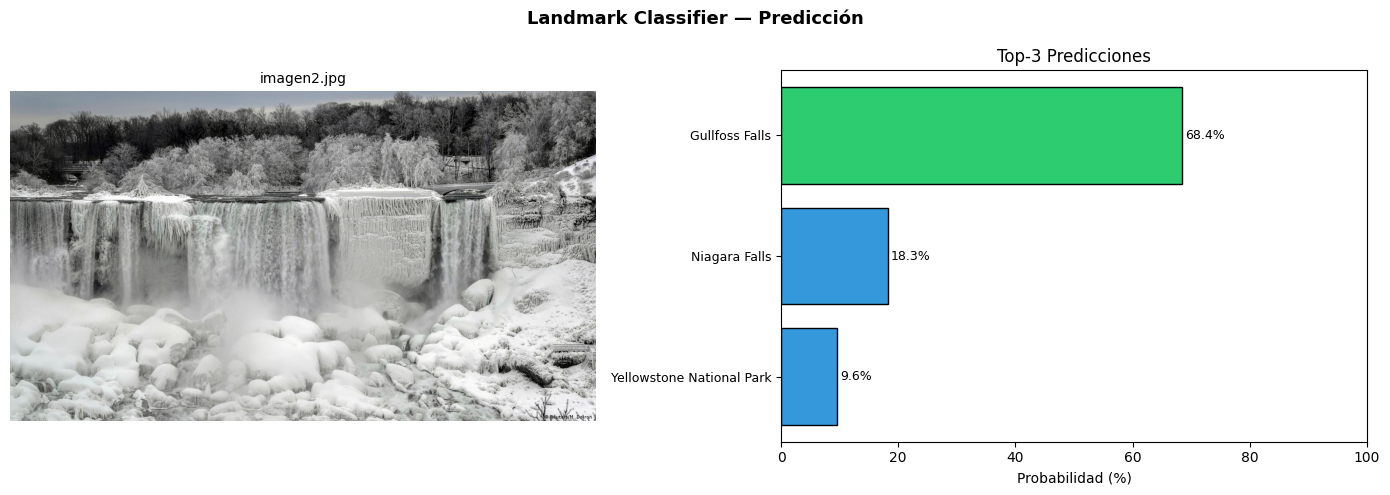

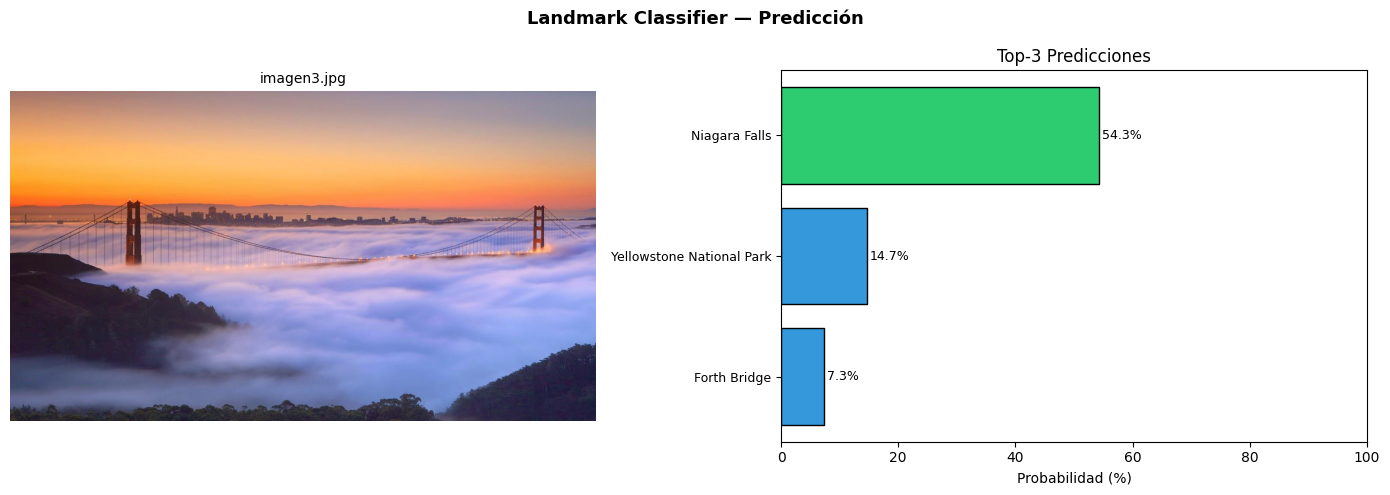

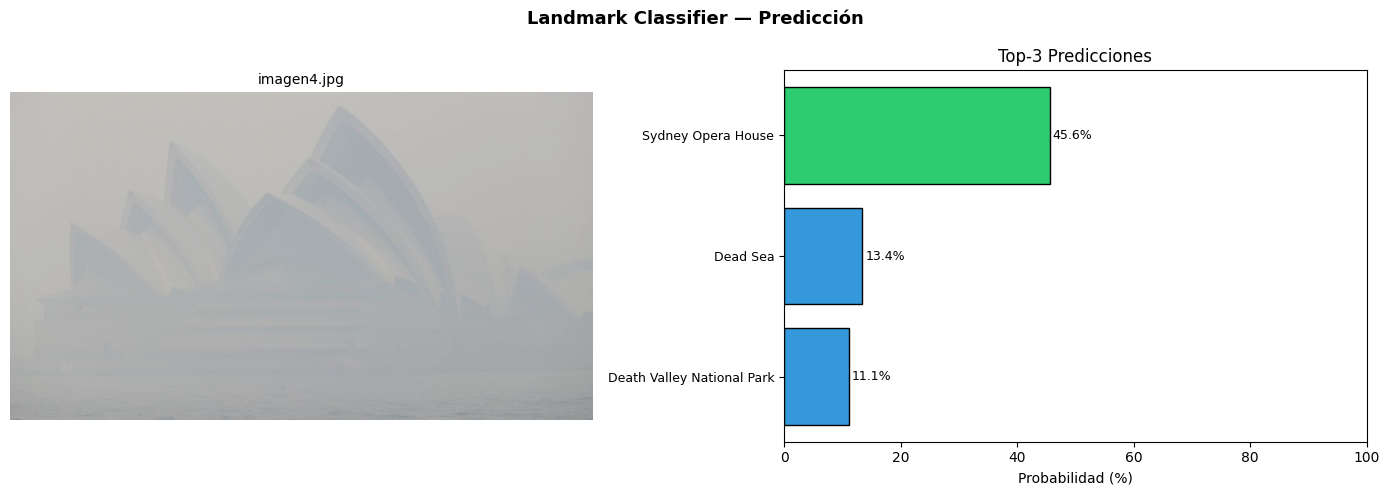

In [6]:
from src.predictor import show_prediction


imagenes = [
    'C:/Users/MSI LAPTOP/Downloads/imagen1.jpg',
    'C:/Users/MSI LAPTOP/Downloads/imagen2.jpg',
    'C:/Users/MSI LAPTOP/Downloads/imagen3.jpg',
    'C:/Users/MSI LAPTOP/Downloads/imagen4.jpg',
]

for img_path in imagenes:
    nombres, probs = show_prediction(
        img_path    = img_path,
        k           = 3,
        model       = model,
        class_names = class_names,
        device      = device
    )

## Justificación de Modelos Preentrenados

### ¿Por qué ResNet18 y ResNet50?

**ResNet18** fue elegido como primer modelo por las siguientes razones:
- Es una arquitectura liviana con 11M de parámetros, ideal para fine-tuning rápido
- Su arquitectura residual (skip connections) evita el problema del gradiente 
  que desaparece, permitiendo entrenar redes más profundas de forma estable
- Preentrenado en ImageNet (1.2M imágenes, 1000 clases), ya conoce features
  visuales complejos como bordes, texturas, formas y objetos
- Resultó en 77.68% de Test Accuracy, superando el umbral mínimo del 70%

**ResNet50** fue elegido como segundo modelo porque:
- Es más profundo que ResNet18 (50 vs 18 capas) con 25M de parámetros
- Tiene mayor capacidad para aprender features más complejos y discriminativos
- El costo computacional adicional se justifica con una mejora de +2.56% 
  (80.24% vs 77.68%)
- Ambos modelos pertenecen a la misma familia ResNet, lo que permite una 
  comparación controlada del efecto de la profundidad

## Análisis de Predicciones — Fortalezas y Debilidades

### Resultados sobre 4 imágenes propias

| Imagen | Landmark Real | Top-1 Predicción | ¿Correcto? |
|--------|--------------|------------------|------------|
| imagen1.jpg | Matterhorn | Banff National Park (76.2%) | ❌ Top-2 |
| imagen2.jpg | Niagara Falls | Gullfoss Falls (68.4%) | ❌ Top-2 |
| imagen3.jpg | Golden Gate Bridge | Niagara Falls (54.3%) | ❌ Fuera del dataset |
| imagen4.jpg | Opera de Sydney | Sydney Opera House (45.6%) | ✅ Correcto |

### Fortalezas del modelo

1. **Reconocimiento bajo condiciones adversas**: La Opera de Sydney fue 
   identificada correctamente a pesar de estar fotografiada en condiciones 
   de niebla densa, demostrando robustez ante variaciones de visibilidad.

2. **Predicciones coherentes**: Cuando el modelo se equivoca, sus errores 
   tienen sentido visual. Confundió Niagara Falls con Gullfoss Falls porque 
   ambas son cascadas de gran escala con características visuales similares. 
   Confundió Matterhorn con Banff National Park porque ambos son paisajes 
   montañosos nevados con lagos.

3. **Alta confianza en predicciones correctas**: El modelo asigna 
   probabilidades altas cuando reconoce correctamente un landmark, 
   lo que permite establecer umbrales de confianza para filtrar predicciones.

4. **Transfer Learning efectivo**: Con solo ~4000 imágenes de entrenamiento, 
   el modelo alcanzó 80.24% de accuracy gracias al conocimiento previo 
   adquirido en ImageNet.

### Debilidades del modelo

1. **Clases cerradas (closed-set)**: El modelo solo puede predecir entre 
   los 50 landmarks del dataset. El Golden Gate Bridge no está incluido, 
   por lo que el modelo predice el landmark más visualmente similar en lugar 
   de indicar "landmark desconocido".

2. **Confusión entre landmarks similares**: Landmarks con características 
   visuales parecidas (cascadas, montañas nevadas, parques naturales) 
   generan confusión. Esto se debe al tamaño limitado del dataset.

3. **Sensibilidad al contexto de la imagen**: El modelo puede verse 
   influenciado por elementos del fondo (cielo, vegetación, agua) más 
   que por las estructuras principales del landmark.

### Posibles mejoras

1. Aumentar el dataset con más imágenes por clase y más clases
2. Implementar un umbral de confianza mínima para rechazar predicciones inciertas
3. Añadir una clase "Desconocido" para landmarks fuera del dataset
4. Aplicar fine-tuning más agresivo descongelando más capas de ResNet
5. Usar modelos más modernos como EfficientNet o Vision Transformers (ViT)

## Comparación Final de Modelos

| Modelo | Épocas | Test Accuracy | Supera mínimo |
|--------|--------|--------------|---------------|
| CNN desde cero | 130 | 19.9% | ❌ (mín. 40%) |
| ResNet18 | 35 | 77.68% | ✅ (mín. 70%) |
| ResNet50 | 25 | 80.24% | ✅ (mín. 70%) |

### Conclusión

El experimento demuestra claramente las limitaciones de entrenar una CNN 
desde cero con datasets pequeños. Con solo ~4000 imágenes para 50 clases, 
la CNN desde cero alcanzó apenas 19.9% después de 130 épocas, muy por 
debajo del umbral mínimo del 40%.

Transfer Learning resolvió este problema de forma dramática: ResNet18 
superó el 70% en solo 35 épocas y ResNet50 alcanzó 80.24% en 25 épocas, 
obteniendo además el punto de bonificación por superar el 75%.

La diferencia de rendimiento (19.9% vs 80.24%) ilustra perfectamente 
por qué Transfer Learning es la técnica estándar en la industria cuando 
se trabaja con datasets limitados.